In [1]:
import allel
import malariagen_data
import dask
import dask.array as da
# silence some dask warnings
dask.config.set(**{'array.slicing.split_large_chunks': True})
from dask.diagnostics.progress import ProgressBar


In [3]:
# Warp frequencies to Dataframe ###
import pandas as pd
import numpy as np
import petl
# Print style
from colorama import Fore, Back, Style

In [4]:
# plotting setup
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import matplotlib_venn as venn
import seaborn as sns

In [5]:
#Mounting Google Drive
import os
os.getcwd()
os.chdir(path='/home/mkient/gitrepos/dsx_works/')
os.makedirs('results_fig',exist_ok=True)

In [8]:
sns.set_context('paper')
sns.set_style('white')
sns.set_style('ticks')
rcParams = plt.rcParams
base_font_size = 8
rcParams['font.size'] = base_font_size
rcParams['axes.titlesize'] = base_font_size
rcParams['axes.labelsize'] = base_font_size
rcParams['xtick.labelsize'] = base_font_size
rcParams['ytick.labelsize'] = base_font_size
rcParams['legend.fontsize'] = base_font_size
rcParams['axes.linewidth'] = .5
rcParams['lines.linewidth'] = .5
rcParams['patch.linewidth'] = .5
rcParams['ytick.direction'] = 'out'
rcParams['xtick.direction'] = 'out'
rcParams['lines.markeredgewidth'] = .5
rcParams['figure.max_open_warning'] = 1000
rcParams['figure.dpi'] = 120
rcParams['figure.facecolor'] = 'w'

%config InlineBackend.figure_format = "retina"
%matplotlib inline

In [11]:
## Importing malariagen data set
ag3 = malariagen_data.Ag3()
ag3

<MalariaGEN Ag3 API client>
Storage URL             : gs://vo_agam_release/
Data releases available : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10
Results cache           : None
Cohorts analysis        : 20240717
AIM analysis            : 20220528
Site filters analysis   : dt_20200416
Software version        : malariagen_data 11.0.0
Client location         : England, United Kingdom
---
Please note that data are subject to terms of use,
for more information see https://www.malariagen.net/data
or contact support@malariagen.net. For API documentation see 
https://malariagen.github.io/malariagen-data-python/v11.0.0/Ag3.html

In [12]:
print(Fore.MAGENTA + 'Processing...', Style.RESET_ALL)
## Let's check the the sample set
sample_TM = ["1191-VO-MULTI-OLOUGHLIN-VMF00106", "1191-VO-MULTI-OLOUGHLIN-VMF00140", "AG1000G-BF-A", "AG1000G-BF-B"]
df_samples = ag3.sample_metadata(sample_sets=sample_TM)#.set_index("sample_id")
from collections import Counter
#Create population column
bf_samples = df_samples.query('country == "Burkina Faso"')
s1, y = [], []
for iso, species in zip(bf_samples.location, bf_samples.aim_species):
    s1.append(iso[:4]+'_'+species[:3])
bf_samples.insert(4, 'population', s1)

# Pop_year
for pop, year in zip(bf_samples.population, bf_samples.year):
    y.append(pop+'_'+str(year))
bf_samples.insert(5, 'pop_year', y)
pop_year = list(bf_samples.pop_year.unique())

cohort_pop, cohort_y = {}, {}
for count, loc, species in zip(bf_samples.country, bf_samples.location, bf_samples.aim_species):
    pop_sp = loc[:4]+'_'+species
    s1.append(pop_sp)
    if species in ['coluzzii', 'gambiae', 'arabiensis'] and count == 'Burkina Faso':
        cohort_pop[pop_sp] = f"country == '{count}' and location == '{loc}' and aim_species == '{species}'"
#cohort_pop

for count, loc, pop, species, year in zip(bf_samples.country, bf_samples.location, bf_samples.population,
                                          bf_samples.aim_species, bf_samples.year):
    pop_y = pop+'_'+str(year)
    y.append(pop_y)
    if species in ['coluzzii', 'gambiae', 'arabiensis'] and count == 'Burkina Faso':
        cohort_y[pop_y] = f"country == '{count}' and location == '{loc}' and aim_species == '{species}' and year == {year}"
#cohort_y.keys()
print(Fore.MAGENTA + 'Done...', Style.RESET_ALL)

Processing... 
Done...                     


In [13]:
## reference genome
print(Fore.MAGENTA + 'done...', Style.RESET_ALL)
df_geneset = ag3.geneset().set_index("ID")
#df_geneset

## let's access to the reference transcript of the gene AGAP004050
#df_geneset.query("Parent == 'AGAP004050'")

## let's choose a transcripts
ra = 'AGAP004050-RA'
rb = 'AGAP004050-RB'
print(Fore.MAGENTA + 'done...', Style.RESET_ALL)

done... 
done...                     


In [14]:
df_geneset.query("start>48703664 and end<48792262").Parent.unique()

array([nan, 'AGAP007648', 'AGAP007648-RA', 'AGAP007649', 'AGAP007649-RA',
       'AGAP007650', 'AGAP007650-RA', 'AGAP007651', 'AGAP007651-RA',
       'AGAP007652', 'AGAP007652-RA', 'AGAP007653', 'AGAP007653-RA',
       'AGAP007654', 'AGAP007654-RD', 'AGAP007654-RB', 'AGAP007654-RC',
       'AGAP007654-RA', 'AGAP007655', 'AGAP007655-RA', 'AGAP007656-RA',
       'AGAP004050-RA', 'AGAP004050-RB', 'AGAP013150', 'AGAP013150-RA',
       'AGAP010088', 'AGAP010088-RA', 'AGAP028324', 'AGAP028324-RA'],
      dtype=object)

In [15]:
df_geneset

,contig,source,type,start,end,score,strand,phase,Parent,Name,description
ID,,,,,,,,,,,
2L,2L,VectorBase,chromosome,1,49364325,NaN,NaN,NaN,NaN,NaN,NaN
AGAP004677,2L,VectorBase,gene,157348,186936,NaN,-,NaN,NaN,NaN,methylenetetrahydrofolate dehydrogenase(NAD ) ...
AGAP004677-RA,2L,VectorBase,mRNA,157348,181305,NaN,-,NaN,AGAP004677,NaN,NaN
NaN,2L,VectorBase,three_prime_UTR,157348,157495,NaN,-,NaN,AGAP004677-RA,NaN,NaN
NaN,2L,VectorBase,exon,157348,157623,NaN,-,NaN,AGAP004677-RA,AGAP004677-RB-E4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
NaN,Y_unplaced,VectorBase,five_prime_UTR,47932,48111,NaN,+,NaN,AGAP029375-RA,NaN,NaN
NaN,Y_unplaced,VectorBase,exon,47932,48138,NaN,+,NaN,AGAP029375-RA,AGAP029375-RA-E2,NaN
AGAP029375-PA,Y_unplaced,VectorBase,CDS,48112,48138,NaN,+,0.0,AGAP029375-RA,NaN,NaN


In [16]:
## Compute SNP allele frequencies by collection site and species
print(Fore.MAGENTA + 'Processing...', Style.RESET_ALL)
#help(ag3.snp_allele_frequencies)
snps_ra = ag3.snp_allele_frequencies(transcript=ra, cohorts=cohort_pop, site_mask='gamb_colu_arab',
                                     sample_sets=sample_TM, drop_invariant=True, effects=True)
snps_rb = ag3.snp_allele_frequencies(transcript=rb, cohorts=cohort_pop, site_mask='gamb_colu_arab',
                                     sample_sets=sample_TM, drop_invariant=True, effects=True)
print(Fore.MAGENTA + 'done...', Style.RESET_ALL)

Processing... 


Load SNP genotypes:   0%|          | 0/208 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/7 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/29200 [00:00<?, ?it/s]

Load SNP genotypes:   0%|          | 0/208 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/7 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/29200 [00:00<?, ?it/s]

done...                     


In [17]:
##non-synomymous
snps_ra.reset_index().query("effect == 'NON_SYNONYMOUS_CODING'").shape

(166, 25)

In [18]:
## in coding region, all region
snps_ra.reset_index().query("effect != 'INTRONIC'").shape, snps_ra.reset_index().shape

((1607, 25), (29200, 25))

In [19]:
### SNP in the gene drive target site ###
gd_snps_ra = snps_ra.reset_index().query("position > 48714000 and position < 48715000")
gd_snps_rb = snps_rb.reset_index().query("position > 48714000 and position < 48715000")
## Creat SNP list
snps_list = [gd_snps_ra, gd_snps_rb]
snps_all = pd.concat(snps_list)
snps_all = snps_all.reset_index().drop_duplicates(subset=['position', 'alt_allele'])
snps_all

,index,contig,position,ref_allele,alt_allele,aa_change,pass_gamb_colu_arab,pass_gamb_colu,pass_arab,frq_Pala_gambiae,...,max_af,transcript,effect,impact,ref_codon,alt_codon,aa_pos,ref_aa,alt_aa,label
0,3077,2R,48714001,G,A,NaN,True,True,True,0.000000,...,0.004870,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,001 G>A"
1,3078,2R,48714001,G,T,NaN,True,True,True,0.021523,...,0.038710,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,001 G>T"
2,3079,2R,48714014,G,C,NaN,True,True,True,0.000000,...,0.045455,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,014 G>C"
3,3080,2R,48714016,G,A,NaN,True,True,True,0.000000,...,0.004425,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,016 G>A"
4,3081,2R,48714022,T,A,NaN,True,True,True,0.000000,...,0.053097,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,022 T>A"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,3370,2R,48714990,T,A,NaN,True,True,True,0.003311,...,0.012903,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,990 T>A"
294,3371,2R,48714992,G,T,NaN,True,True,True,0.003311,...,0.009740,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,992 G>T"
295,3372,2R,48714997,C,G,NaN,True,True,True,0.001656,...,0.005952,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,997 C>G"
296,3373,2R,48714998,A,T,NaN,True,True,True,0.000000,...,0.004115,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,998 A>T"


In [20]:
# Subset allelic frequencies
sub_snps_all = snps_all.query('position > 48714420 and position < 48714720 and max_af > 0.01')
len(sub_snps_all)

8

In [21]:
# Subset allelic frequencies
sub_snps = snps_all.query('position > 48714400 and position < 48714800')
sub_snps

,index,contig,position,ref_allele,alt_allele,aa_change,pass_gamb_colu_arab,pass_gamb_colu,pass_arab,frq_Pala_gambiae,...,max_af,transcript,effect,impact,ref_codon,alt_codon,aa_pos,ref_aa,alt_aa,label
134,3211,2R,48714401,G,C,NaN,True,True,True,0.000000,...,0.092920,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,401 G>C"
135,3212,2R,48714407,C,T,NaN,True,True,True,0.000000,...,0.003247,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,407 C>T"
136,3213,2R,48714418,C,T,NaN,True,True,True,0.000000,...,0.003247,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,418 C>T"
137,3214,2R,48714439,C,T,NaN,True,True,True,0.001656,...,0.001656,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,439 C>T"
138,3215,2R,48714445,C,A,NaN,True,True,True,0.018212,...,0.022581,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,445 C>A"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,3289,2R,48714787,C,A,NaN,True,True,True,0.000000,...,0.004425,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,787 C>A"
213,3290,2R,48714789,T,C,NaN,True,True,True,0.000000,...,0.005952,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,789 T>C"
214,3291,2R,48714790,A,T,NaN,True,True,True,0.034768,...,0.035714,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,790 A>T"
215,3292,2R,48714792,G,A,NaN,True,True,True,0.000000,...,0.004425,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,792 G>A"


In [27]:
# Subset allelic frequencies
sub_snps_all1 = snps_all.query('position > 48714420 and position < 48714720')
sub_snps_all1.to_csv('data_tables/dsx_allelic_freq_new.csv')
sub_snps_all1

,index,contig,position,ref_allele,alt_allele,aa_change,pass_gamb_colu_arab,pass_gamb_colu,pass_arab,frq_Pala_gambiae,...,max_af,transcript,effect,impact,ref_codon,alt_codon,aa_pos,ref_aa,alt_aa,label
137,3214,2R,48714439,C,T,NaN,True,True,True,0.001656,...,0.001656,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,439 C>T"
138,3215,2R,48714445,C,A,NaN,True,True,True,0.018212,...,0.022581,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,445 C>A"
139,3216,2R,48714445,C,T,NaN,True,True,True,0.008278,...,0.017857,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,445 C>T"
140,3217,2R,48714448,A,T,NaN,True,True,True,0.000000,...,0.002058,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,448 A>T"
141,3218,2R,48714449,C,A,NaN,True,True,True,0.000000,...,0.002058,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,449 C>A"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,3276,2R,48714704,C,A,NaN,True,True,True,0.000000,...,0.004425,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,704 C>A"
200,3277,2R,48714707,A,G,NaN,True,True,True,0.000000,...,0.030973,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,707 A>G"
201,3278,2R,48714708,C,T,NaN,True,True,True,0.000000,...,0.005952,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,708 C>T"
202,3279,2R,48714714,T,A,NaN,True,True,True,0.000000,...,0.004870,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,714 T>A"


In [23]:
## Compute SNP allele frequencies by year
print(Fore.MAGENTA + 'Processing...', Style.RESET_ALL)
#help(ag3.snp_allele_frequencies)
snps_ra_y = ag3.snp_allele_frequencies(transcript=ra, cohorts=cohort_y, site_mask='gamb_colu_arab',
                                       sample_sets=sample_TM, drop_invariant=True, effects=True)
snps_rb_y = ag3.snp_allele_frequencies(transcript=rb, cohorts=cohort_y, site_mask='gamb_colu_arab',
                                       sample_sets=sample_TM, drop_invariant=True, effects=True)
print(Fore.MAGENTA + 'done...', Style.RESET_ALL)

Processing... 


Load SNP genotypes:   0%|          | 0/208 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/26 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/28519 [00:00<?, ?it/s]

Load SNP genotypes:   0%|          | 0/208 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/26 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/28519 [00:00<?, ?it/s]

done...                     


In [24]:
### SNP in the gene drive target site ###
gd_snps_ra_y = snps_ra_y.reset_index().query("position > 48714000 and position < 48715000")
gd_snps_rb_y = snps_rb_y.reset_index().query("position > 48714000 and position < 48715000")
## Creat SNP list
snps_list_y = [snps_ra_y, snps_rb_y]
snps_year = pd.concat(snps_list_y)
snps_year = snps_year.reset_index().drop_duplicates(subset=['position', 'alt_allele'])
#snps_year#.columns

In [25]:
#snps_year.query('position==48714486')

In [28]:
# Subset allelic frequencies
sub_snps_year = snps_year.query('position > 48714420 and position < 48714720')
sub_snps_year.to_csv('data_tables/data1_new.csv')
sub_snps_year = snps_year.query('position > 48714420 and position < 48714720 and max_af > 0.02')
sub_snps_year

,contig,position,ref_allele,alt_allele,aa_change,pass_gamb_colu_arab,pass_gamb_colu,pass_arab,frq_Pala_gam_2014,frq_Sour_gam_2014,...,max_af,transcript,effect,impact,ref_codon,alt_codon,aa_pos,ref_aa,alt_aa,label
3145,2R,48714445,C,A,NaN,True,True,True,0.022472,0.020408,...,0.035714,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,445 C>A"
3146,2R,48714445,C,T,NaN,True,True,True,0.011236,0.020408,...,0.022727,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,445 C>T"
3150,2R,48714453,G,A,NaN,True,True,True,0.050562,0.061224,...,0.113636,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,453 G>A"
3152,2R,48714468,G,C,NaN,True,True,True,0.005618,0.000000,...,0.020833,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,468 G>C"
3156,2R,48714473,G,T,NaN,True,True,True,0.000000,0.020408,...,0.038462,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,473 G>T"
3159,2R,48714486,C,A,NaN,True,True,True,0.016854,0.010204,...,0.500000,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,486 C>A"
3161,2R,48714494,C,A,NaN,True,True,True,0.000000,0.000000,...,0.022727,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,494 C>A"
3162,2R,48714494,C,G,NaN,True,True,True,0.000000,0.000000,...,0.021739,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,494 C>G"
3174,2R,48714538,C,T,NaN,True,True,True,0.000000,0.000000,...,0.023810,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,538 C>T"
3183,2R,48714617,C,T,NaN,True,True,True,0.000000,0.000000,...,0.022727,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,617 C>T"


In [29]:
# Subset allelic frequencies
sub_snps_year1 = snps_year.query('position > 48714600 and position < 48714680')
sub_snps_year1

,contig,position,ref_allele,alt_allele,aa_change,pass_gamb_colu_arab,pass_gamb_colu,pass_arab,frq_Pala_gam_2014,frq_Sour_gam_2014,...,max_af,transcript,effect,impact,ref_codon,alt_codon,aa_pos,ref_aa,alt_aa,label
3183,2R,48714617,C,T,NaN,True,True,True,0.0,0.0,...,0.022727,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,617 C>T"
3184,2R,48714641,C,A,NaN,True,True,True,0.0,0.0,...,0.005682,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,641 C>A"
3185,2R,48714652,T,C,NaN,True,True,True,0.0,0.0,...,0.017857,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,652 T>C"
3186,2R,48714671,G,T,NaN,True,True,True,0.0,0.0,...,0.017241,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,671 G>T"
3187,2R,48714672,A,G,NaN,True,True,True,0.0,0.0,...,0.017241,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,672 A>G"
3188,2R,48714676,G,A,NaN,True,True,True,0.0,0.0,...,0.038462,AGAP004050-RA,INTRONIC,MODIFIER,None,None,NaN,None,None,"2R:48,714,676 G>A"


In [30]:
## Preparing plot
#cohorts = cohort_.copy()
#keys = ['BFA (An. arabiensis)', 'CMR (An. arabiensis)', 'MLI (An. arabiensis)']
#list(map(cohorts.pop, keys))
#cohorts

color_1 = sns.light_palette("darkslategray",n_colors=100)
color_2 = sns.color_palette("ch:s=16,rot=0.05,dark=0.18,light=0.99", as_cmap=True)
#color_2 = sns.color_palette("ch:s=16,rot=0.05,dark=0.18,light=0.99", as_cmap=True)
color_1

[(0.9243251607982169, 0.9485808685681695, 0.9484666801442928),
 (0.9185211495408991, 0.9435708532975848, 0.9434575604691895),
 (0.9098151326549224, 0.9360558303917079, 0.9359438809565347),
 (0.9040111213976045, 0.9310458151211233, 0.9309347612814314),
 (0.8953051045116278, 0.9235307922152463, 0.9234210817687765),
 (0.88950109325431, 0.9185207769446616, 0.9184119620936733),
 (0.8807950763683333, 0.9110057540387847, 0.9108982825810183),
 (0.8720890594823566, 0.9034907311329077, 0.9033846030683634),
 (0.8662850482250388, 0.898480715862323, 0.8983754833932602),
 (0.8575790313390621, 0.8909656929564461, 0.8908618038806053),
 (0.8517750200817443, 0.8859556776858615, 0.8858526842055021),
 (0.8430690031957676, 0.8784406547799845, 0.8783390046928472),
 (0.8343629863097909, 0.8709256318741075, 0.8708253251801923),
 (0.8285589750524731, 0.8659156166035229, 0.8658162055050891),
 (0.8198529581664963, 0.8584005936976459, 0.8583025259924342),
 (0.8140489469091785, 0.8533905784270612, 0.853293406317331),
 (0.8053429300232018, 0.8458755555211843, 0.8457797268046761),
 (0.799538918765884, 0.8408655402505997, 0.8407706071295727),
 (0.7908329018799073, 0.8333505173447227, 0.8332569276169179),
 (0.7821268849939306, 0.8258354944388457, 0.825743248104263),
 (0.7763228737366128, 0.8208254791682611, 0.8207341284291597),
 (0.7676168568506361, 0.8133104562623841, 0.8132204489165049),
 (0.7618128455933182, 0.8083004409917994, 0.8082113292414016),
 (0.7531068287073415, 0.8007854180859225, 0.8006976497287467),
 (0.7444008118213647, 0.7932703951800455, 0.7931839702160919),
 (0.738596800564047, 0.788260379909461, 0.7881748505409886),
 (0.7298907836780703, 0.7807453570035839, 0.7806611710283337),
 (0.7240867724207525, 0.7757353417329993, 0.7756520513532305),
 (0.7153807555347758, 0.7682203188271224, 0.7681383718405755),
 (0.709576744277458, 0.7632103035565376, 0.7631292521654722),
 (0.7008707273914813, 0.7556952806506607, 0.7556155726528174),
 (0.6921647105055045, 0.7481802577447838, 0.7481018931401625),
 (0.6863606992481868, 0.7431702424741992, 0.7430927734650592),
 (0.67765468236221, 0.7356552195683221, 0.7355790939524044),
 (0.6718506711048922, 0.7306452042977375, 0.7305699742773011),
 (0.6631446542189154, 0.7231301813918606, 0.7230562947646462),
 (0.6544386373329387, 0.7156151584859836, 0.7155426152519914),
 (0.6486346260756208, 0.7106051432153989, 0.710533495576888),
 (0.6399286091896442, 0.703090120309522, 0.7030198160642331),
 (0.6341245979323265, 0.6980801050389374, 0.6980106963891299),
 (0.6254185810463497, 0.6905650821330603, 0.690497016876475),
 (0.616712564160373, 0.6830500592271834, 0.6829833373638201),
 (0.6109085529030551, 0.6780400439565988, 0.6779742176887169),
 (0.6022025360170784, 0.6705250210507218, 0.670460538176062),
 (0.5963985247597606, 0.6655150057801371, 0.6654514185009588),
 (0.5876925078737839, 0.6579999828742602, 0.6579377389883039),
 (0.5818884966164661, 0.6529899676036754, 0.6529286193132007),
 (0.5731824797304894, 0.6454749446977985, 0.6454149398005458),
 (0.5644764628445127, 0.6379599217919216, 0.6379012602878908),
 (0.5586724515871948, 0.6329499065213369, 0.6328921406127876),
 (0.5499664347012181, 0.62543488361546, 0.6253784611001327),
 (0.5441624234439004, 0.6204248683448754, 0.6203693414250295),
 (0.5354564065579236, 0.6129098454389983, 0.6128556619123746),
 (0.526750389671947, 0.6053948225331214, 0.6053419823997197),
 (0.5209463784146291, 0.6003848072625368, 0.6003328627246165),
 (0.5122403615286524, 0.5928697843566597, 0.5928191832119615),
 (0.5064363502713345, 0.5878597690860752, 0.5878100635368583),
 (0.4977303333853579, 0.5803447461801983, 0.5802963840242035),
 (0.49192632212804, 0.5753347309096135, 0.5752872643491),
 (0.48322030524206333, 0.5678197080037366, 0.5677735848364452),
 (0.47451428835608667, 0.5603046850978597, 0.5602599053237904),
 (0.4687102770987688, 0.5552946698272749, 0.555250785648687),
 (0.4600042602127921, 0.547779646921398, 0.5477371061360322),
 (0.4542002489554743, 0.5427696316508134, 0.54272798646

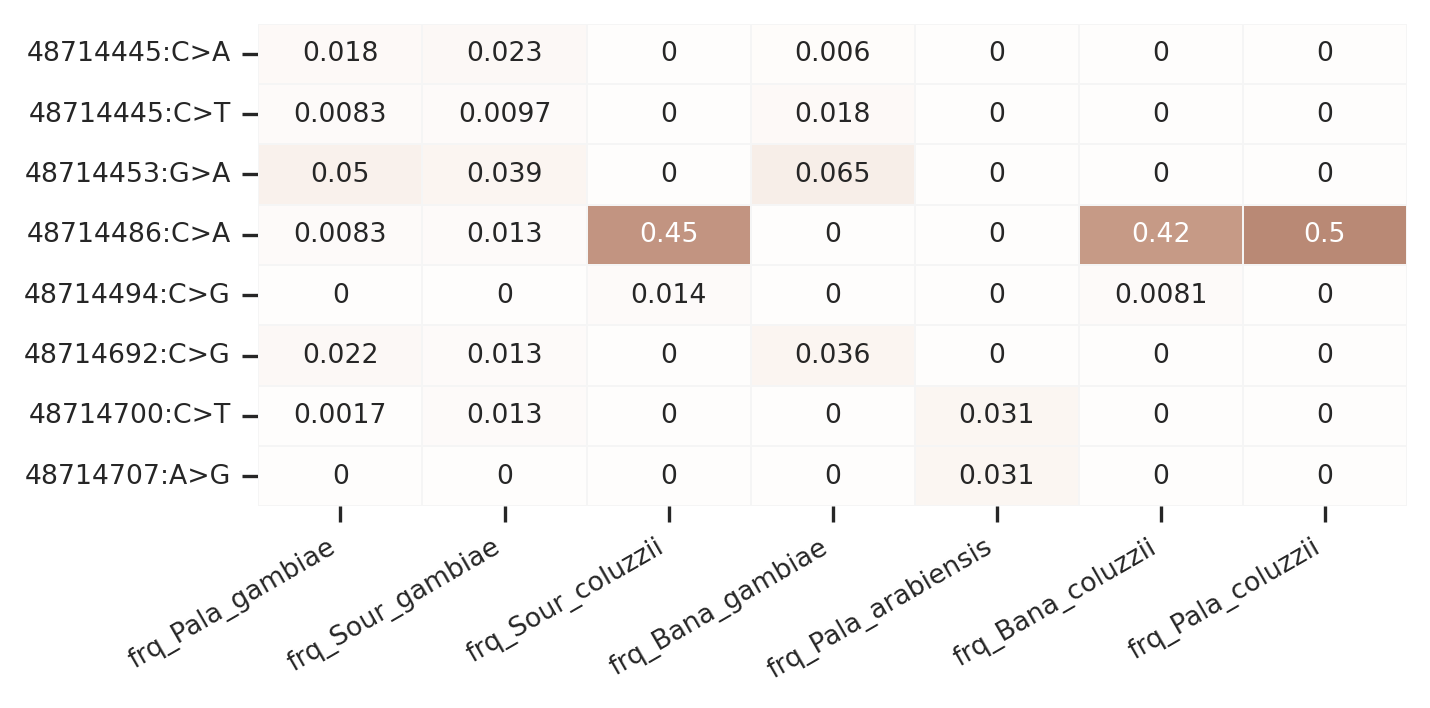

In [31]:
# plot allele freqs per pop
fig = plt.figure(figsize=(6,3))
ptl_df = petl.fromdataframe(sub_snps_all)
columns = ['frq_Pala_gambiae', 'frq_Sour_gambiae', 'frq_Sour_coluzzii', 'frq_Bana_gambiae',
           'frq_Pala_arabiensis', 'frq_Bana_coluzzii','frq_Pala_coluzzii']
labels = ['%s:%s>%s' % (rec.position, rec.ref_allele, rec.alt_allele) for rec in ptl_df.records()]
# plot
ax=sns.heatmap(sub_snps_all[columns],vmin=0,vmax=1,cmap=color_2, yticklabels=labels,linewidths=0.5,
               linecolor="whitesmoke",annot=True, cbar=False)
#ax.set_title("Alternative alleles frequencies per population within the AGAP004050 gene")
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
fig.savefig('results_fig/plot_fq_species', dpi=300, bbox_inches='tight')

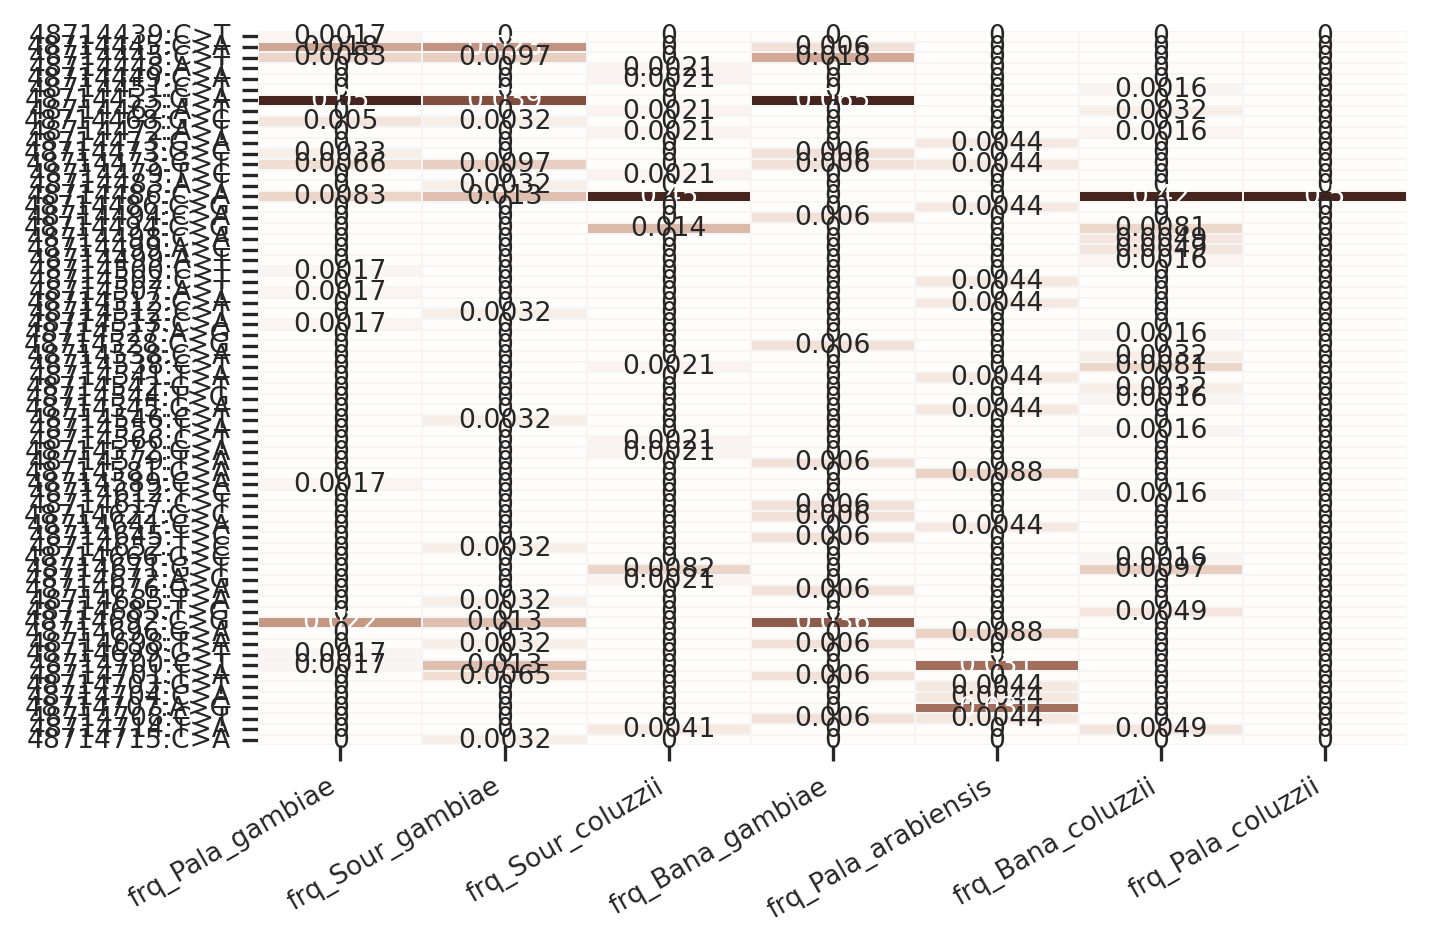

In [32]:
# plot allele freqs per pop
fig = plt.figure(figsize=(6,4))
ptl_df = petl.fromdataframe(sub_snps_all1)
columns = ['frq_Pala_gambiae', 'frq_Sour_gambiae', 'frq_Sour_coluzzii', 'frq_Bana_gambiae',
           'frq_Pala_arabiensis', 'frq_Bana_coluzzii','frq_Pala_coluzzii']
labels = ['%s:%s>%s' % (rec.position, rec.ref_allele, rec.alt_allele) for rec in ptl_df.records()]
# plot
ax=sns.heatmap(sub_snps_all1[columns],vmin=0,vmax=0.05,cmap=color_2, yticklabels=labels,linewidths=0.5,
               linecolor="whitesmoke",annot=True, cbar=False)
#ax.set_title("Alternative alleles frequencies per population within the AGAP004050 gene")
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
fig.savefig('data_tables/plot_fq_species1', dpi=300, bbox_inches='tight')

In [33]:
## col_name
columns = ['frq_Bana_gam_2012', 'frq_Sour_gam_2012', 'frq_Pala_gam_2012','frq_Bana_col_2012',
           'frq_Sour_col_2012', 'frq_Pala_col_2012', 'frq_Bana_gam_2014', 'frq_Sour_gam_2014',
           'frq_Pala_gam_2014', 'frq_Bana_col_2014', 'frq_Sour_col_2014', 'frq_Pala_ara_2014',
           'frq_Sour_gam_2015', 'frq_Pala_gam_2015', 'frq_Bana_col_2015', 'frq_Sour_col_2015',
           'frq_Pala_ara_2015', 'frq_Bana_gam_2016', 'frq_Sour_gam_2016', 'frq_Pala_gam_2016',
           'frq_Bana_col_2016', 'frq_Sour_col_2016', 'frq_Pala_ara_2016', 'frq_Pala_gam_2017',
           'frq_Bana_col_2017', 'frq_Sour_col_2017']
columns1 = ['frq_Bana_gam_2012', 'frq_Sour_gam_2012', 'frq_Pala_gam_2012','frq_Bana_col_2012',
           'frq_Sour_col_2012', 'frq_Pala_col_2012', 'frq_Bana_gam_2014', 'frq_Sour_gam_2014',
           'frq_Pala_gam_2014', 'frq_Bana_col_2014', 'frq_Sour_col_2014', 'frq_Pala_ara_2014',
           'frq_Sour_gam_2015', 'frq_Pala_gam_2015', 'frq_Bana_col_2015', 'frq_Sour_col_2015',
           'frq_Pala_ara_2015', 'frq_Bana_gam_2016', 'frq_Sour_gam_2016', 'frq_Pala_gam_2016',
           'frq_Bana_col_2016', 'frq_Sour_col_2016', 'frq_Pala_ara_2016', 'frq_Pala_gam_2017',
           'frq_Bana_col_2017', 'frq_Sour_col_2017']
labs = ['An. gambiae ss (BN, 2012)', 'An. gambiae ss (SK, 2012)', 'An. gambiae ss (PL, 2012)',
        'An. coluzzii (BN, 2012)', 'An. coluzzii (SK, 2012)', 'An. coluzzii (PL, 2012)',
        'An. gambiae ss (BN, 2014)', 'An. gambiae ss (SK, 2014)', 'An. gambiae ss (PL, 2014)',
        'An. coluzzii (BN, 2014)', 'An. coluzzii (SK, 2014)',
        'An. arabiensis (PL, 2014)',
        'An. gambiae ss (SK, 2015)', 'An. gambiae ss (PL, 2015)',
        'An. coluzzii (BN, 2015)', 'An. coluzzii (SK, 2015)',
        'An. arabiensis (PL, 2015)',
        'An. gambiae ss (BN, 2016)', 'An. gambiae ss (SK, 2016)', 'An. gambiae ss (PL, 2016)',
        'An. coluzzii (BN, 2016)', 'An. coluzzii (SK, 2016)',
        'An. arabiensis (PL, 2016)',
        'An. gambiae ss (PL, 2017)',
        'An. coluzzii (BN, 2017)', 'An. coluzzii (SK, 2017)',
       ]

/tmp/ipykernel_8491/344502576.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


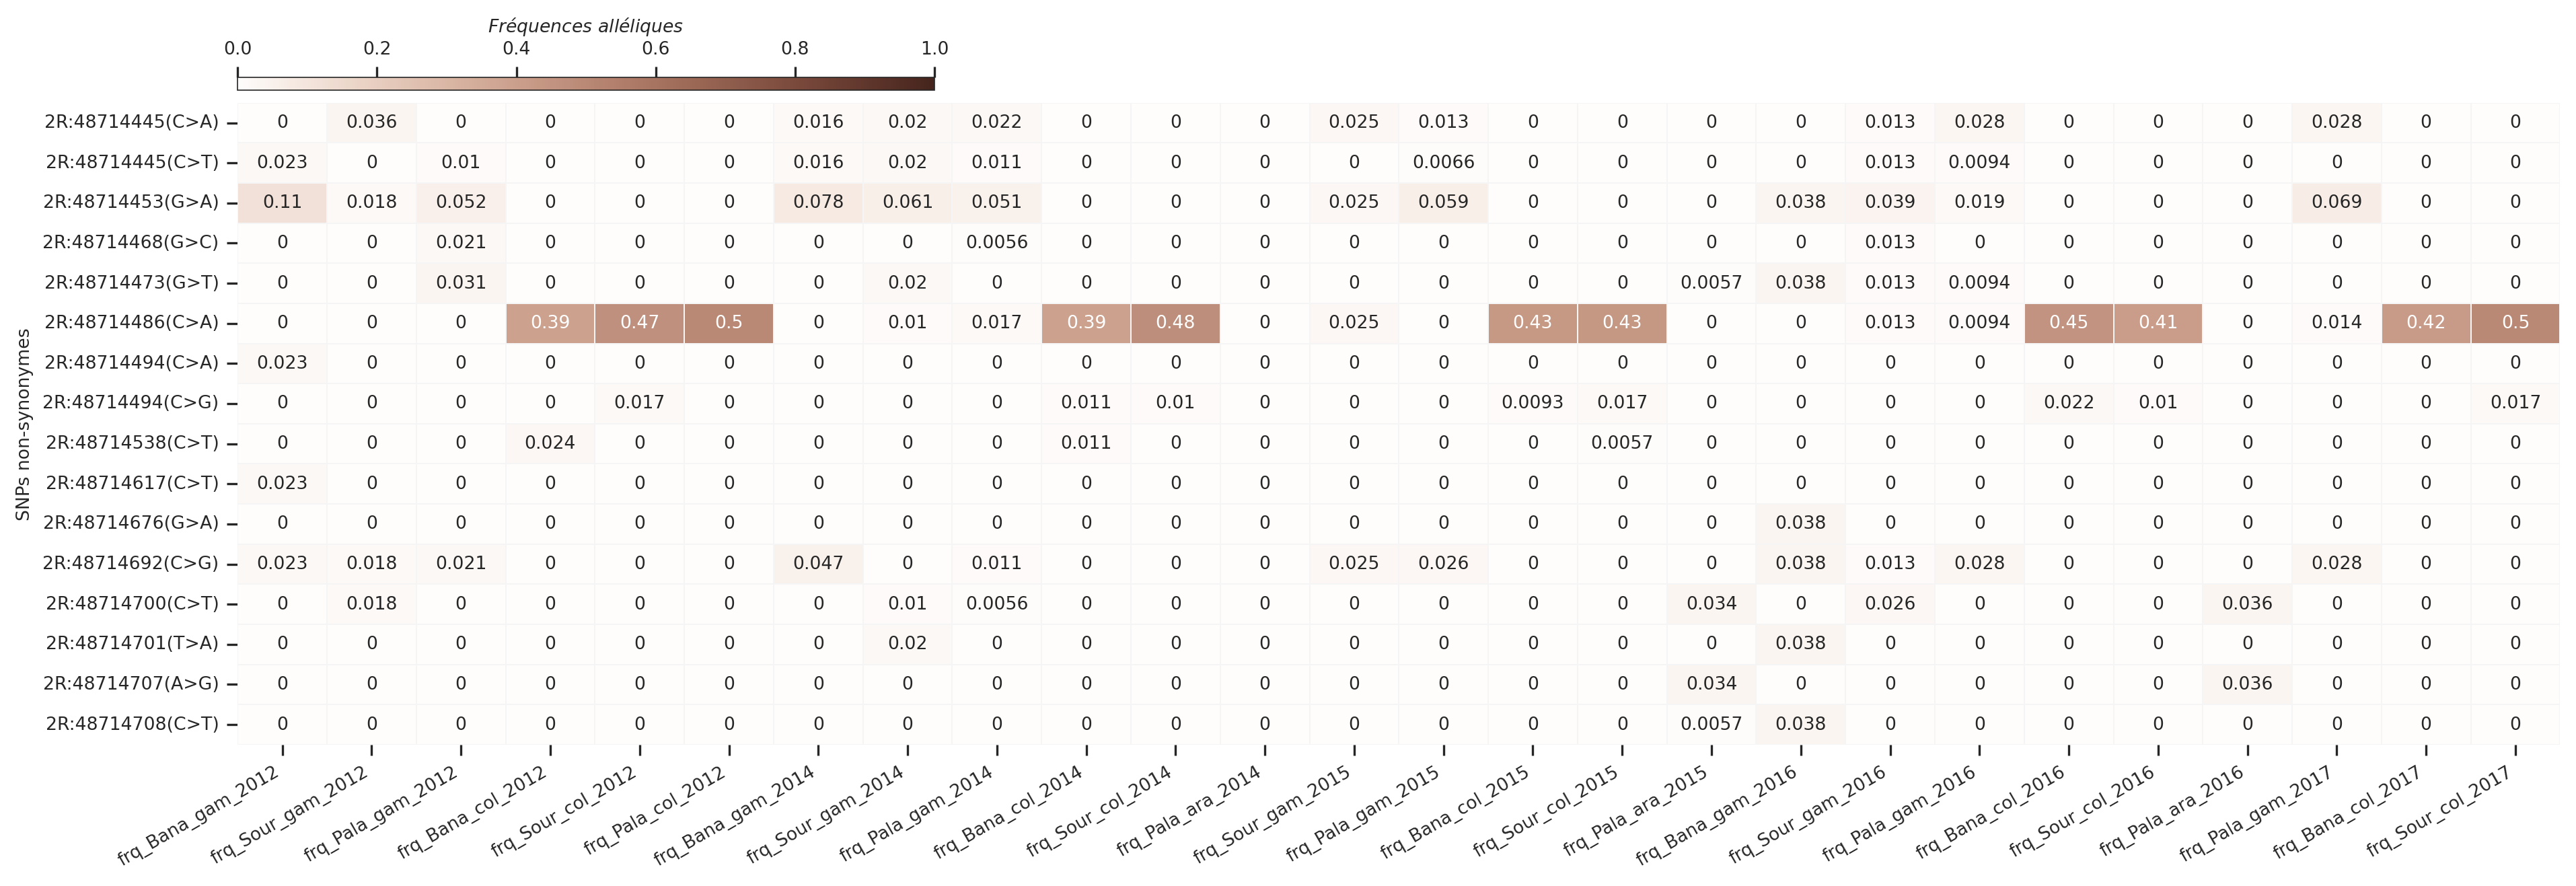

In [34]:
# plot allele freqs per pop
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, ax = plt.subplots(figsize=(16,5))
#fig = plt.figure(figsize=(15,5))
ptl_df = petl.fromdataframe(sub_snps_year)

labels = ['2R:%s(%s>%s)' % (rec.position, rec.ref_allele, rec.alt_allele) for rec in ptl_df.records()]
# plot
ax1=sns.heatmap(sub_snps_year[columns],vmin=0,vmax=1,cmap=color_2, yticklabels=labels,linewidths=0.5,
               linecolor="whitesmoke",annot=True, cbar=False)
#ax.set_title("Alternative alleles frequencies per population within the AGAP004050 gene")
plt.xticks(rotation=30, ha='right')

ax1.set_ylabel('SNPs non-synonymes')
cax = inset_axes(ax,width="30%", height="2%", loc='lower left', bbox_to_anchor=(0, 1.02, 1, 1),
                 bbox_transform=ax.transAxes,borderpad=0)
mpl.colorbar.ColorbarBase(cax,orientation='horizontal', ticklocation='top',cmap=color_2,
                         label='$Fréquences$ $alléliques$')
fig.tight_layout()
fig.savefig('results_fig//plot_fq_year.png', dpi=300, bbox_inches='tight')

In [ ]:
#sub_snps_year.columns

In [35]:
columns = ['frq_Bana_gam_2012', 'frq_Sour_gam_2012', 'frq_Pala_gam_2012','frq_Bana_col_2012',
           'frq_Sour_col_2012', 'frq_Pala_col_2012', 'frq_Bana_gam_2014', 'frq_Sour_gam_2014',
           'frq_Pala_gam_2014', 'frq_Bana_col_2014', 'frq_Sour_col_2014', 'frq_Pala_ara_2014',
           'frq_Sour_gam_2015', 'frq_Pala_gam_2015', 'frq_Bana_col_2015', 'frq_Sour_col_2015',
           'frq_Pala_ara_2015', 'frq_Bana_gam_2016', 'frq_Sour_gam_2016', 'frq_Pala_gam_2016',
           'frq_Bana_col_2016', 'frq_Sour_col_2016', 'frq_Pala_ara_2016', 'frq_Pala_gam_2017',
           'frq_Bana_col_2017', 'frq_Sour_col_2017']
len(columns)

26